연합뉴스 타이틀을 주제별로 분류해 보겠다. 즉, 제목을 놓고 범주를 맞춘다.  
단어 가방 모형을 사용해 텍스트를 학습시키고 분류한 결과가 정답과 일치하는지 확인해본다.

# 데이터 수집하기

사용할 데이터는 `데이콘 경진대회`를 검색한 후 데이콘(DACON, AI 경진대회 플랫폼) 사이트에서 다운로드 받는다.

<img src="./데이콘1.png" width="1200" align="left" />

검색 아이콘(돋보기)를 클릭한다.

<img src="./데이콘2.png" width="1200" align="left" />

검색어에 `KLUE`를 입력하고 `월간 데이콘 뉴스 토픽 분류 AI 경진대회`를 클릭한다.

<img src="./데이콘3.png" width="1200" align="left" />

`데이터` 탭에서 `다운로드` 버튼을 클릭해서 다운로드 받는다.

<img src="./데이콘4.png" width="1200" align="left" />

데이터 다운로드 경로: https://dacon.io/competitions/official/235747/data

KLUE(Korean Language Understanding Evaluation, 한국어 자연어 이해 벤치마크 데이터셋) 데이터를 경진대화용으로 재분류한 데이터이다. 이 데이터에는 뉴스의 타이틀만 있고 용량이 작아서 초보자가 입문용으로 사용하기에 적합하다.

# 분류 과정

머신러닝을 이용해서 뉴스 타이틀 텍스트를 분석할 것이다. 데이터 로드, 전처리를 거쳐 머신러닝 모델로 학습, 예측, 평가한다.

<img src="./분류과정.png" width="1000" align="left" />

머신러닝 과정은 우리가 어떤 내용을 공부하고 시험을 보는 과정과 유사하다. 예를 들어 어떤 자격증을 따기 위해 시험을 본다면, 우리는 기출 문제를 공부하고 시험을 보러 갈 것이다. 기출 문제는 정답이 있자만, 시험 문제는 정답이 없다. 데이터 예측도 마찬가지다. 머신러닝은 학습 데이터셋으로 학습하고, 테스트 데이터셋으로 예측한다. 학습 데이터는 정답이 있지만 테스트 데이터에는 정답이 없다.

# 분류를 위한 기본 설정

## 라이브러리 불러오기

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [2]:
# !pip install konlpy
# !pip install tqdm

# 데이터 불러오기

train.shape, test.shape로 확인해보면 학습 데이터셋에는 45,654개의 데이터가 들어있고, 테스트 데이터셋에는 9,131개의 데이터가 들어있다. 열은 3과 2로 출력되는데, 이 차이는 다음과 같이 학습 데이터와 테스트 데이터에 모두 들어있는 열(index(인덱스), title(뉴스 타이틀))이 있고, 정답에 해당하는 topic_idx 값은 테스트 데이터셋에는 들어있지 않기 때문이다.

학습 데이터: train_data.csv(index, title, topic_idx)  
테스트 데이터: test_data.csv(index, title)

In [3]:
train = pd.read_csv('./data/train_data.csv')
test = pd.read_csv('./data/test_data.csv')
print(train.shape, test.shape)

(45654, 3) (9131, 2)


In [4]:
train.head()

,index,title,topic_idx
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4


In [5]:
test.head()

,index,title
0,45654,유튜브 내달 2일까지 크리에이터 지원 공간 운영
1,45655,어버이날 맑다가 흐려져…남부지방 옅은 황사
2,45656,내년부터 국가RD 평가 때 논문건수는 반영 않는다
3,45657,김명자 신임 과총 회장 원로와 젊은 과학자 지혜 모을 것
4,45658,회색인간 작가 김동식 양심고백 등 새 소설집 2권 출간


`범주`를 확인해 보자. 뉴스 타이틀이 정치, 경제 등의 범주 중 어디에 속하는지를 토픽 분류 문제로 다룰 예정이다.  
topic_idx를 보면 총 7개의 뉴스 기사 범주로 구성되어 있다. 이제부터 뉴스 타이틀을 통해 이 범주값을 학습하고 예측하는 모델을 만들 것이다.

범주 데이터: topic_dict.csv(topic, topic_idx)

In [6]:
topic = pd.read_csv('./data/topic_dict.csv')
topic

,topic,topic_idx
0,IT과학,0
1,경제,1
2,사회,2
3,생활문화,3
4,세계,4
5,스포츠,5
6,정치,6


In [7]:
topic['topic'].values

<StringArray>
['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']
Length: 7, dtype: str

# 데이터 전처리하기

문자 길이, 단어의 등장 빈도 등을 확인하고 시각화해 봄으로써 전체적인 데이터의 특성을 파악한다. 다음으로 불필요한 기호 등을 제거한 후 중요한 정보를 담고 있는 내용을 추출해 본다.

데이터 전처리는 학습 데이터셋과 테스트 데이터셋에 모두 적용해 주어야 전처리한 내용대로 학습하고 예측할 수 있다. 학습 데이터셋과 테스트 데이터셋을 각각 전처리할 수 도 있지만, 실수를 줄이기 위해 두 데이터셋을 병합해서 전처리한 후 다시 나누는 방법을 사용한다.

## 데이터 전처리를 위한 데이터 병합

우선 두 데이터셋을 병합한다. 판다스의 concat() 메소드로 학습 데이터셋과 테스트 데이터셋을 하나의 데이터프레임으로 만들어 준다. concat() 메소드의 axis 속성의 기본값은 0이므로 별도로 지정하지 않아도 학습 데이터셋 아래로 테스트 데이터셋이 병합되는 것을 확인할 수 있다.

In [8]:
# 학습 데이터셋 아래쪽으로 테스트 데이터셋을 이어 붙인다.
raw_df = pd.concat([train, test])
raw_df.shape

(54785, 3)

In [9]:
raw_df.head()

,index,title,topic_idx
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4.0
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4.0
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4.0
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4.0
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4.0


In [10]:
raw_df.tail()

,index,title,topic_idx
9126,54780,인천 오후 3시35분 대설주의보…눈 3.1cm 쌓여,NaN
9127,54781,노래방에서 지인 성추행 외교부 사무관 불구속 입건종합,NaN
9128,54782,40년 전 부마항쟁 부산 시위 사진 2점 최초 공개,NaN
9129,54783,게시판 아리랑TV 아프리카개발은행 총회 개회식 생중계,NaN
9130,54784,유영민 과기장관 강소특구는 지역 혁신의 중심…지원책 강구,NaN


## 데이터 전처리를 위한 데이터 병합

다음으로 merge() 메소드로 학습 데이터셋 아래쪽으로 테스트 데이터셋을 이어 붙인 데이터프레임에 topic의 원래 명칭을 붙여준다.  
raw_df(학습 데이터셋과 테스트 데이터셋을 병합한) 데이터프레임에 topic 데이터프레임 merge() 메소드로 병합한다. merge() 메소드는 두 데이터프레임의 공통의 행을 키값으로 연결한다. 여기서는 두 데이터프레임에 모두 `topic_idx`라는 열이 있으므로 해당 열을 기준으로 데이터를 병합한다. 이때, how 속성값을 `left`로 설정하면 왼쪽 데이터프레임을 기준으로 병합한다.

In [11]:
# 학습 데이터셋 아래쪽으로 테스트 데이터셋을 이어 붙인 데이터프레임에 topic 데이터프레임의 topic을 병합한다.
df = raw_df.merge(topic, how='left')
df.shape

(54785, 4)

In [12]:
df.head()

,index,title,topic_idx,topic
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4.0,세계
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4.0,세계
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4.0,세계
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4.0,세계
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4.0,세계


In [13]:
df.tail()

,index,title,topic_idx,topic
54780,54780,인천 오후 3시35분 대설주의보…눈 3.1cm 쌓여,NaN,NaN
54781,54781,노래방에서 지인 성추행 외교부 사무관 불구속 입건종합,NaN,NaN
54782,54782,40년 전 부마항쟁 부산 시위 사진 2점 최초 공개,NaN,NaN
54783,54783,게시판 아리랑TV 아프리카개발은행 총회 개회식 생중계,NaN,NaN
54784,54784,유영민 과기장관 강소특구는 지역 혁신의 중심…지원책 강구,NaN,NaN


## 정답값 빈도수 확인

학습 데이터셋에 제공하는 정답값을 빈도수를 구해서 예측해야 하는 값의 빈도수가 비슷한지 아니면 차이가 있지를 확인한다.  
value_counts() 메소드의 dropna 속성의 기본값은 True이므로 테스트 데이터셋은 topic_idx 열이 결측치(missing value, 데이터에 값이 없는 것)이므로 빈도수에 포함되지 않는다. 만약에 결측치도 빈도수에 포함시키려면 dropna 속성의 속성값을 False로 지정하면 된다.

In [14]:
df['topic'].value_counts()

topic
세계      7629
사회      7362
스포츠     6933
정치      6751
경제      6222
생활문화    5933
IT과학    4824
Name: count, dtype: int64

빈도를 더 직관적으로 이해하기 위해 빈도수를 구해서 막대 그래프를 그려주는 countplot() 메소드를 사용해서 시각화해 보자.

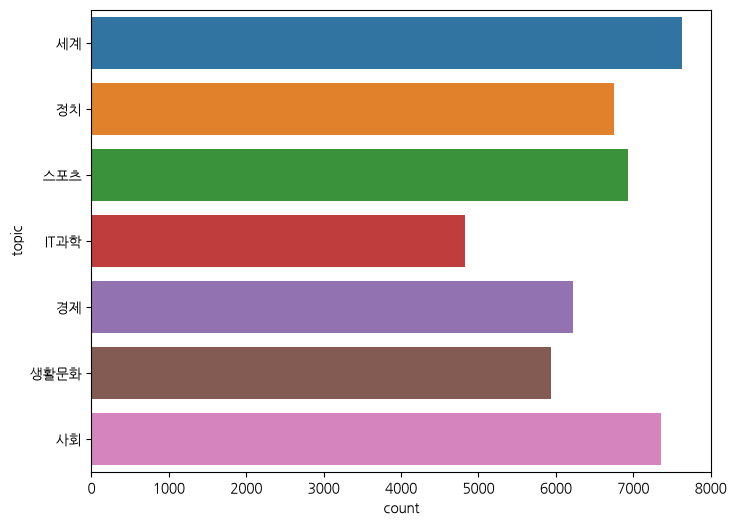

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, y='topic', hue='topic', legend=False)
plt.show()

시각화 결과를 보면 뉴스 기사의 토픽별로 세계에 해당하는 문서가 가장 많고, IT과학에 해당하는 문서가 가장 적다. 이처럼 데이터 불균형이 있을 때는 어떻게 할까?  
무작위 추출을 통해 데이터가 가장 적은 IT과학의 개수에 맞춰 다른 토픽의 데이터를 삭제할 수도 있고(under sampling), 아니면 IT과학의 개수를 늘려서 가장 개수가 많은 세계에 맞출 수도 있다(over sampling). 이외에 이상치 탐지를 통해 경계가 모호한 데이터를 미리 삭제할 수도 있다. 다만, 이렇게 데이터를 삭제하는 경우 중요 정보를 잃을 수도 있으므로 각 방법의 장단점을 고려해서 가장 적합한 방법을 선택해야 한다.

## 문자 길이 확인

길이가 긴 텍스트는 의미를 학습하기에 충분하고, 길이가 짧으면 불충분할 것이다. 그래서 천처리할 때 문자 길이도 확인하는 습관을 가지면 좋다. 학습이 끝난 후 성능 향상을 위한 계획을 세울 때 단어 빈도 또는 문자 길이 등을 유용하게 사용하기도 한다.

In [16]:
df['len'] = df.title.apply(lambda x: len(x)) # 뉴스 제목을 구성하는 문자의 개수
df['word_count'] = df.title.apply(lambda x: len(x.split())) # 뉴스 제목을 구성하는 단어의 개수
df['unique_word_count'] = df.title.apply(lambda x: len(set(x.split()))) # 뉴스 제목을 구성하는 중복을 제외한 단어의 개수
df.head()

,index,title,topic_idx,topic,len,word_count,unique_word_count
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4.0,세계,24,5,5
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4.0,세계,30,6,6
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4.0,세계,30,8,8
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4.0,세계,32,7,7
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4.0,세계,25,7,7


## 문자 길이 확인를 히스토그램으로 시각화

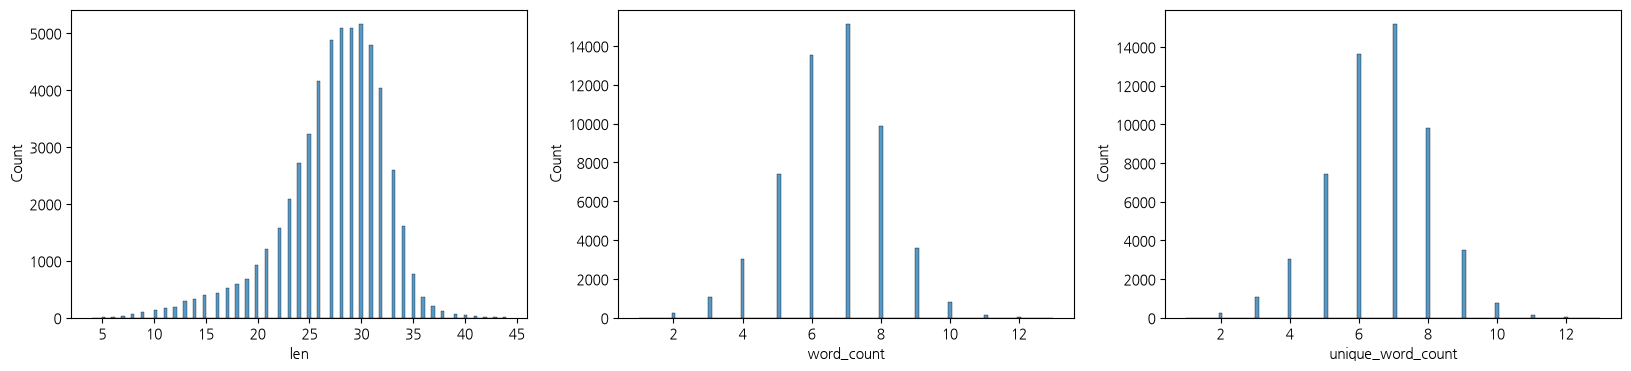

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
sns.histplot(df.len, ax=axes[0])
sns.histplot(df.word_count, ax=axes[1])
sns.histplot(df.unique_word_count, ax=axes[2])
plt.show()

연합뉴스 기사에서 제목만 추출했기 때문에 글자수 25 ~ 32개 사이에 빈도수가 몰려있고, 단어 수도 6 ~ 8개 내외로 구성되어 있다.

describe() 메소드를 사용해서 기술 통계량을 알아보자.  
낱글자의 길이(len)와 단어 빈도(word_count), 유일 어절(unique_word_count)의 빈도(count), 평균(mean), 표준편차(std) 외에도 최소값(min), 최대값(max), 그리고 사분위수에 해당하는 25%, 50%(중위수, median), 75% 범위를 표시해서 데이터 분포를 나타낼 수 있다.

In [18]:
df[['len', 'word_count', 'unique_word_count']].describe()

,len,word_count,unique_word_count
count,54785.000000,54785.000000,54785.000000
mean,27.318846,6.587880,6.576198
std,4.947738,1.471852,1.465320
min,4.000000,1.000000,1.000000
25%,25.000000,6.000000,6.000000
50%,28.000000,7.000000,7.000000
75%,31.000000,8.000000,8.000000
max,44.000000,13.000000,13.000000


## 주제별 글자와 단어의 빈도 확인

토픽별로 토픽을 구성하는 문자 개수 시각화

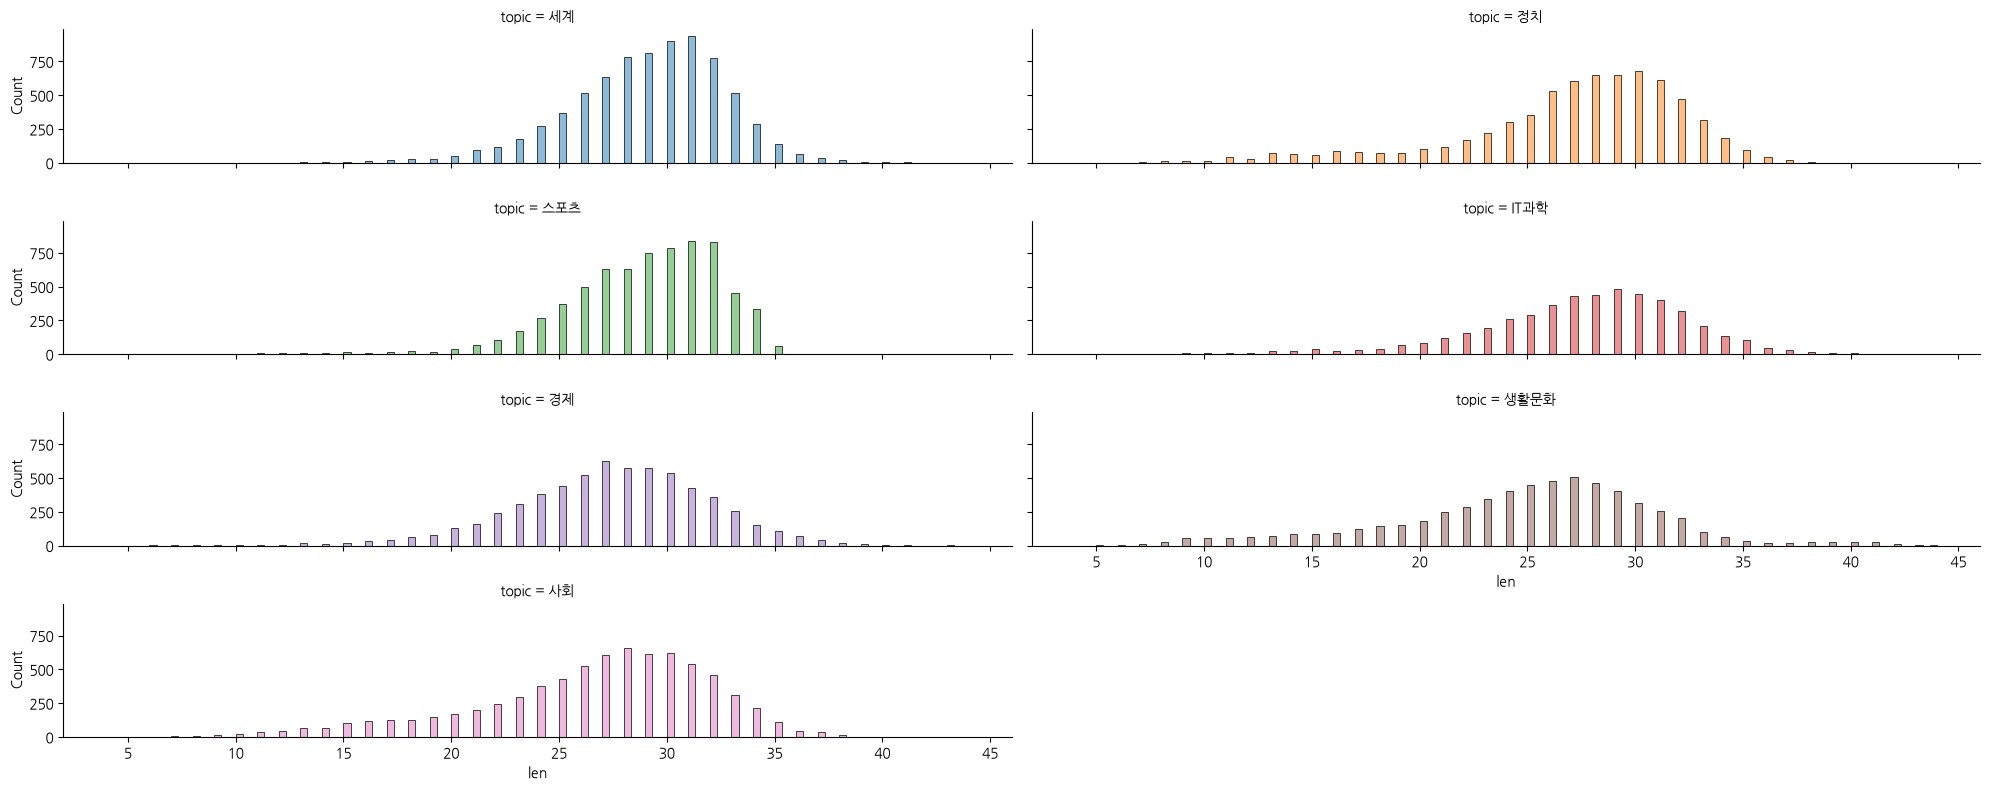

In [19]:
# 데이터프레임 df에서 단어 수에 해당하는 열 'len'을 x축으로, 'topic'별 빈도를 y축으로 한다.
sns.displot(data=df, x='len', hue='topic', col='topic', col_wrap=2, height=2, aspect=5, legend=False)
plt.show()

토픽별로 단어 수의 분포를 큰 차이는 없지만 IT과학, 생활문화는 y축 값이 다른 주제에 비해 빈도가 적다. 이를 정답값의 빈도수와 비교해 볼 피요가 있다.

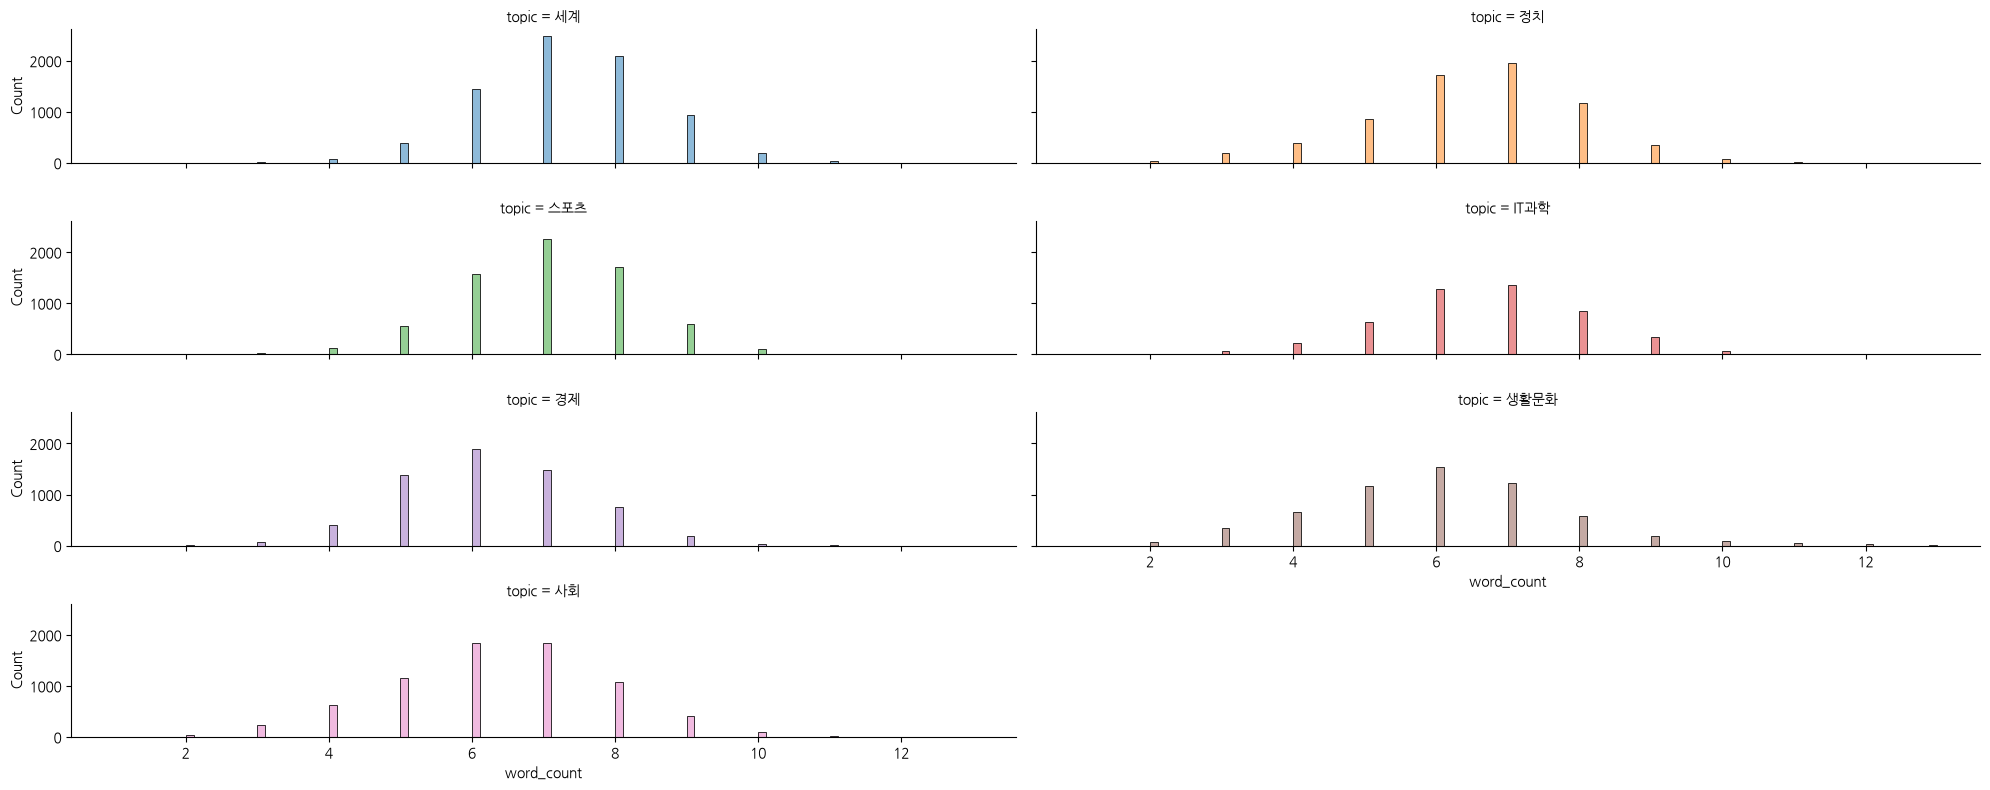

In [20]:
sns.displot(data=df, x='word_count', hue='topic', col='topic', col_wrap=2, height=2, aspect=5, legend=False)
plt.show()

유일 어절(unique_word_count) 빈도값도 시각화해 보자.

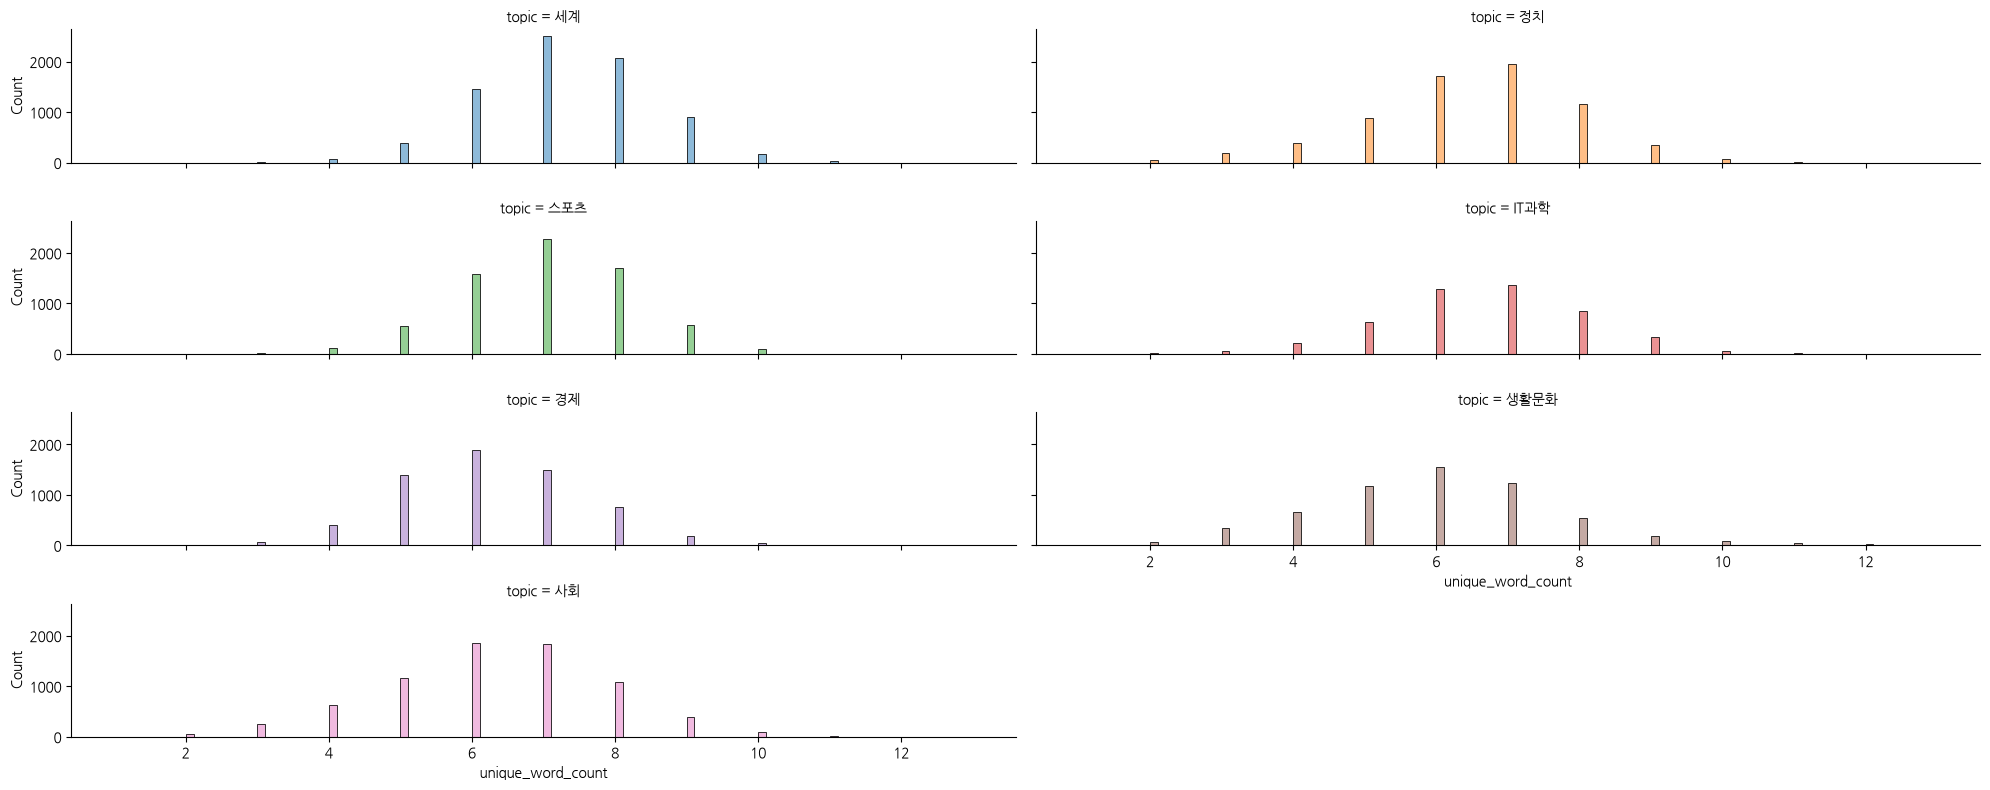

In [21]:
sns.displot(data=df, x='unique_word_count', hue='topic', col='topic', col_wrap=2, height=2, aspect=5, legend=False)
plt.show()

# 문자 전처리하기

단어 가방 모형은 단어를 띄어쓰기 같은 기준으로 나누어 벡터화하므로, 대소문자나 숫자 등에 따라 중복된 단어 사전이 생성되기도 한다.  
단어 사전이 너무 많아지면 학습 속도가 오래 걸리거나 과적합이 발생할 수 있다. 간단히 말해 과적합은 불필요하지만 자주 나오는 단어를 모델이 중요하게 여기고 학습하는 것이다. 이런 경우 특정 단어를 중심으로 학습이 끝나면, 테스트 데이터에 새로운 단어가 있을 때 예측력이 떨어지는 주요한 요인이 된다. 따라서, 전처리 단계에서 불필요한 단어를 제거해 모델의 성능을 올려줘야 한다.

전처리 방법으로는 불필요한 문자를 제거하나, 형태소 분석기를 사용해서 불필요한 조사를 제거하거나, 형태소를 표기해서 같은 단어지만 다른 의미를 갖는 단어를 구분해 줄 수도 있다.

## 숫자 제거

숫자는 학습과 예측에 중요한 역할을 하기 때문에 충분히 이해한 뒤 사용 여부를 결정해야 한다. 이번 예제에서는 숫자가 큰 의미가 없으므로 제외한다.

파이썬에서 정규 표현식(Regular Expressions)을 사용하기 위해 기본 라이브러리인 `re`를 import 한다.  
정규 표현식 특정 규칙을 가지는 문자열의 집합을 표현하는 언어로, 복잡한 문자열 검색, 추출, 치환 등의 작업을 수행할 때 사용한다.

주요 메소드  
`search(패턴, 문자열)`: 문자열 전체를 검색해서 패턴과 일치하는 첫 번째 위치를 찾는다.  
`match(패턴, 문자열)`: 문자열의 시작 부분이 패턴과 일치하는지 확인한다.  
`findall(패턴, 문자열)`: 패턴과 일치하는 모든 부분을 찾아서 리스트로 리턴한다.  
`sub(패턴, 치환할 문자열, 찾을 문자열)`: 찾을 문자열에서 패턴과 일치하는 부분을 치환할 문자열로 치환한다.  
compile(패턴): 동일한 패턴을 여러번 사용할 경우, 미리 컴파일해서 실행 속도를 높인다.

In [22]:
import re

정규 표현식에서 `대괄호`는 문자 클래스를 의미한다. 대괄호 안에 들어가는 문자들 중 `단 하나(1개)`의 문자라도 일치하면 매칭된다.  
`[a, b, c]`: a, b, c 중 문자 1개와 일치, `[cb]at` 패턴을 적용하면 cat, bat, hat 중에서 cat, bat와 매칭된다.  
대괄호 안에서 `-`을 사용하면 문자의 연속된 범위를 지정할 수 있다.  
`[0-9]`: 숫자 1개, 0부터 9사이의 모든 숫자. `\d`와 같은 표현이다.  
`[a-z]`: 소문자 알파벳 1개  
`[A-Z]`: 대문자 알파벳 1개  
`[a-zA-Z]`: 알파벳 1개  
`[a-zA-Z0-9]`: 알파벳 또는 숫자 1개  
`[ㄱ-힣]`: 한글 1개  
`^`는 나오는 위치에 따라서 2가지 의미로 사용된다.  
① `부정/제외`: 대괄호 안쪽 맨 앞에 `^`를 붙이면 `해당 문자를 제외한 나머지`를 의미한다. [`^`0-9]는 숫자를 제외한 모든 문자  
② `문자열의 시작`: 패턴 맨 앞에 `^`를 붙이면 `문자열의 시작 부터 검색`을 의미한다. `^`[0-9]는 문자열의 시작 부터 검색

In [23]:
# 뉴스 제목에서 모든 숫자를 찾아서 공백으로 치환한다. 제거한다.
# df['title'] = df.title.map(lambda x: re.sub('[0-9]', '', x))
# 시리즈의 replace() 메소드로 정규식을 실행할 수 있다.
# regex 속성의 기본값은 False이고 replace() 메소드의 첫 번째 인자를 문자열로 취급하고, True를 지정하면 문자열이 아닌 정규 표현식으로 처리하겠다는 의미이다.
df['title'] = df.title.str.replace('[0-9]', '', regex=True)

## 영문자는 모두 소문자로 변경

컴퓨터는 같은 단어라도 대문자냐 소문자냐에 따라 다르게 분류한다. 현재 데이터는 영어의 대소문자를 서로 다른 단어로 인식할 필요가 없으므로 한쪽으로 통일한다. 여기서는 모두 소문자로 변환한다.

In [24]:
df['title'] = df.title.str.lower()

## 형태소 분석기로 조사, 어미, 구두점 제거

특정 단어를 제외하거나 선택하고 싶다면 다음과 같은 방법들이 있다.

ㆍ불용어 목록을 지정하는 방법  
ㆍKoNLPy에서 품사를 지정해 추출하는 방법  
ㆍNoun 추출기를 이용하는 방법

여기서는 KoNLPy의 형태소 분석기(Open Korean Text, Okt)를 사용해서 품사를 태깅하고 조사, 어미, 구두점을 제거해 보자.

먼저 Okt를 불러와 간단한 문장에 품사 태깅을 실행해 보면서, 품사 태깅에 대해서 알아보자.

In [25]:
from konlpy.tag import Okt

In [26]:
text = '아버지가 방에 들어가신다.'
%time Okt().pos(text)

CPU times: total: 15.7 s
Wall time: 4.41 s


[('아버지', 'Noun'),
 ('가', 'Josa'),
 ('방', 'Noun'),
 ('에', 'Josa'),
 ('들어가신다', 'Verb'),
 ('.', 'Punctuation')]

위의 코드를 실행한 결과를 보면, Okt().pos()가 각 품사를 태깅한 모습을 볼 수 있다. 이때 `품사를 태깅한다`의 의미는 텍스트가 주어졌을 때 이를 `형태소` 단위로 나누고, 나눠진 형태소를 해당하는 `품사`와 함께 리스트로 만드는 것이다.

이제 뉴스 데이터에서 조사, 어미, 구두점을 제거한다.  
okt_clean() 함수로 텍스트를 받아서 품사를 태깅한 후 반복문으로 조사, 어미, 구두점이 있는지 확인하고 그 외의 토큰을 리스트에 넣어준다.  
반복문이 종료되면 리스트 형태의 토큰들을 문자열 메소드 join()을 사용해 공백을 사이에 넣어서 연결한다.  
형태소 분석기로 조사, 어미, 구두점을 제거해 주면 같은 의미의 단어이지만 다른 단어로 토큰화하는 것을 방지해 희소 행렬 크기를 줄일 수 있다.

In [27]:
okt = Okt()

# 조사, 어미, 구두점을 제거하고 어간을 추출하는 함수
def okt_clean(text):
    clean_text = []
    # stem 속성의 기본값은 False이고 형태소 분석 결과를 모두 다른 단어로 취급하고 True로 지정하면 변형된 단어를 사전형 기본형(원형)으로 정규화해 한다.
    for word in okt.pos(text, stem=True):
        # print(word)
        if word[1] not in ['Josa', 'Eomi', 'Punctuation']:
            clean_text.append(word[0])
    return ' '.join(clean_text)

In [28]:
from tqdm import tqdm
tqdm.pandas()

전처리 함수를 적용할 때는 함수 내부에서 품사 태깅과 어간 추출 결과를 반복문을 사용해 전처리하기 때문에 작업이 오래 걸린다. 이 때, tqdm 라이브러리를 사용하면 작업의 진행 정도를 시각적으로 확인할 수 있다.

In [29]:
# df.title.map(okt_clean)
df['title'] = df.title.progress_map(okt_clean)

100%|██████████| 54785/54785 [00:43<00:00, 1262.28it/s]


## 불용어 제거

의미 없는 단어, 즉 불용어가 너무 많이 등장하면 문서의 특성이 잘 드러나지 않는다. 이처럼 의미 없는 단어, 욕설 등을 제거하려는 용어를 불용어 목록에 미리 저장해 두고 삭제할 수 있다.  
주의할 점은 조사를 지우기 위해 '이'나 '은'을 불용어 목록으로 지정하면 조사만 삭제되는 것이 아니라 온전한 의미를 지니는 명사까지 삭제될 수 있다는 점이다. 예를 들어 '이빨'의 '이'나 '금은'의 '은'도 삭제된다. 이럴 때는 위에서 사용했던 형태소 분석기를 통해 품사를 지정해 추출하거나 Noun 추출기를 사용해 명사만 추출할 수 있다.

In [30]:
# 불용어를 제거하는 함수
def remove_stopwords(text):
    tokens = text.split(' ')
    stops = ['합니다', '하는', '할', '하고', '한다', '하다', '그리고', '입니다', '그', '등', '이런', '것', '및', '제', '더', '없다', '되다', '조원', '억원'
            '대다', '보다', '있다']
    # tokens에 저장된 단어(t)가 불용어(stops)에 포함되지 않은 경우 리스트로 만든다.
    result = [t for t in tokens if t not in stops]
    return ' '.join(result)

In [31]:
df['title'] = df.title.progress_map(remove_stopwords)

100%|██████████| 54785/54785 [00:00<00:00, 129481.11it/s]


In [32]:
df.head()

,index,title,topic_idx,topic,len,word_count,unique_word_count
0,0,인천 → 핀란드 항공기 결항 휴가 철 여행객 분통,4.0,세계,24,5,5
1,1,실리콘밸리 넘어서다 구글 들이다 美 전역 거점 화,4.0,세계,30,6,6
2,2,이란 외무 긴장 완화 해결 책 미국 경제 전쟁 멈추다,4.0,세계,30,8,8
3,3,nyt 클린턴 측근 韓 기업 특수 관계 조명 공과 사 맞다 물리다 종합,4.0,세계,32,7,7
4,4,시진핑 트럼프 중미 무역 협상 조속 타결 희망,4.0,세계,25,7,7


# 학습, 테스트 데이터셋 분리하기

이것으로 전처리가 끝났다. 이제 학습 데이터셋과 테스트 데이터셋으로 다시 분리한다. 정답값인 topic_idx 값 여부에 따라 데이터를 나눌 수 있다.

판다스의 concat() 메소드로 병합한 후 확인할 때 테스트 데이터셋의 topic_idx는 NaN이었다. 따라서 notnull() 메소드와 isnull() 메소드를 사용해서 NaN이 아니면 학습 데이터셋, NaN이면 테스트 데이터셋으로 재분할 한다.

In [33]:
train = df[df.topic_idx.notnull()]
test = df[df.topic_idx.isnull()]
print(train.shape, test.shape)

(45654, 7) (9131, 7)


학습, 테스트 데이터셋에서 피쳐 분리하기

In [34]:
x_train = train.title
x_test = test.title
print(x_train.shape, x_test.shape)

(45654,) (9131,)


학습, 테스트 데이터셋에서 레이블 분리하기

In [35]:
y_train = train.topic_idx
y_test = test.topic_idx
print(y_train.shape, y_test.shape)

(45654,) (9131,)


# 단어 벡터화 하기

이제 머신러닝에서 텍스트를 처리하는 방법에 대해서 알아보자. 머신러닝이나 딥러닝 알고리즘은 문자를 이해할 수 없다. 따라서 인코딩 과정은 단어를 숫자로 바꿔 계산하는 과정이라고 볼 수 있다. 문자를 숫자로 변경해 주는 과정은 다음과 같다.
<br><br>
<img src="./입력문장의인코딩과정.png" width="900" align="left" />

ㆍ입력 문장  
랭곤은 명사(고유명사)의 예시로 사용했다. 위의 그림에 사용한 문장은 잘 정돈되어 있지만 자연어 문장은 대체로 그렇치 않다. '안녕' 같이 매우 짧은 문장부터 몇 줄씩 이어지는 긴 문장이 한꺼번에 나오기도 한다.

ㆍ토큰화  
요리에서 재료를 정리하고 적합한 크기로 잘라주는 과정이 필요한 것 처럼, 자연어 처리도 이와 같은 작업이 필요하고. 이를 `토큰화(tokenization)` 작업이라 부른다.

ㆍ인코딩  
토큰화 작업으로 잘 정돈한 언어 재료는 벡터를 표현할 수 있는 인코딩 과정을 거친다. 단어 벡터를 만드는 작업을 위해 사이킷런을 사용해 보자.

In [36]:
import sklearn
sklearn.set_config(display='text')
from sklearn.feature_extraction.text import TfidfVectorizer

사이킷런의 TfidfVectorizer()를 사용해서 TF-IDF 변환을 실행하기 위해 모델을 만들고 학습시킨다.

In [37]:
tfidfvect = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95)
tfidfvect.fit(x_train)

TfidfVectorizer(max_df=0.95, min_df=3, ngram_range=(1, 2))

학습한 모델을 적용시킨다. transform() 메소드로 단어 문서 행렬로 변환되어 숫자 형태로 변환된다.

In [38]:
x_train_tfidf = tfidfvect.transform(x_train)
x_test_tfidf = tfidfvect.transform(x_test)
print(x_train_tfidf.shape, x_test_tfidf.shape)

(45654, 25352) (9131, 25352)


get_feature_names_out() 메소드로 생성된 단어 사전을 얻어올 수 있다.

In [39]:
vocab = tfidfvect.get_feature_names_out()
print(len(vocab))
print(vocab[:20])

25352
['aa' 'abs' 'abu' 'ac' 'ac 밀란' 'acl' 'acl 차다' 'afc' 'afc 챔스리그'
 'afc 챔피언스리그' 'afc 챔피언십' 'afc 회장' 'afp' 'ag' 'ag 대표팀' 'ag 우승' 'ag 축구' 'ai'
 'ai 가다' 'ai 개발']


넘파이의 toarray() 메소드를 실행하면 희소 행렬을 넘파이 배열로 확인할 수 있다.

In [40]:
x_train_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(45654, 25352))

희소 행렬을 판다스 데이터프레임 형태로 변환하면 단어 사전과 함께 희소 행렬 볼 수 있다.

In [41]:
pd.DataFrame(x_train_tfidf.toarray(), columns=vocab)

,aa,abs,abu,ac,ac 밀란,acl,acl 차다,afc,afc 챔스리그,afc 챔피언스리그,...,힐러리 지지,힐러리 트럼프,힐링,힘겹다,힘내다,힘드다,힘들다,힘쓰다,힘차다,힙합
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45650,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


전체 단어 사전에서 가중치 값의 합계를 계산하기 위해 넘파이의 sum() 메소드를 사용한다.  
sum() 메소드의 axis 속성의 기본값은 None이고 전체 배열의 합계를 계산하고, 속성값을 0으로 지정하면 열 방향 합계를 1로 지정하면 행 방향 합계를 계산한다.

In [47]:
dist = np.sum(x_train_tfidf, axis=0)
vocab_count = pd.DataFrame(dist, columns=vocab)
vocab_count

,aa,abs,abu,ac,ac 밀란,acl,acl 차다,afc,afc 챔스리그,afc 챔피언스리그,...,힐러리 지지,힐러리 트럼프,힐링,힘겹다,힘내다,힘드다,힘들다,힘쓰다,힘차다,힙합
0,1.638704,1.448351,1.443645,1.178914,1.178914,4.714391,1.368398,10.483243,3.615705,1.249048,...,1.191286,9.487656,6.009768,1.924272,4.036454,5.519273,10.379933,1.316283,1.852401,2.356838


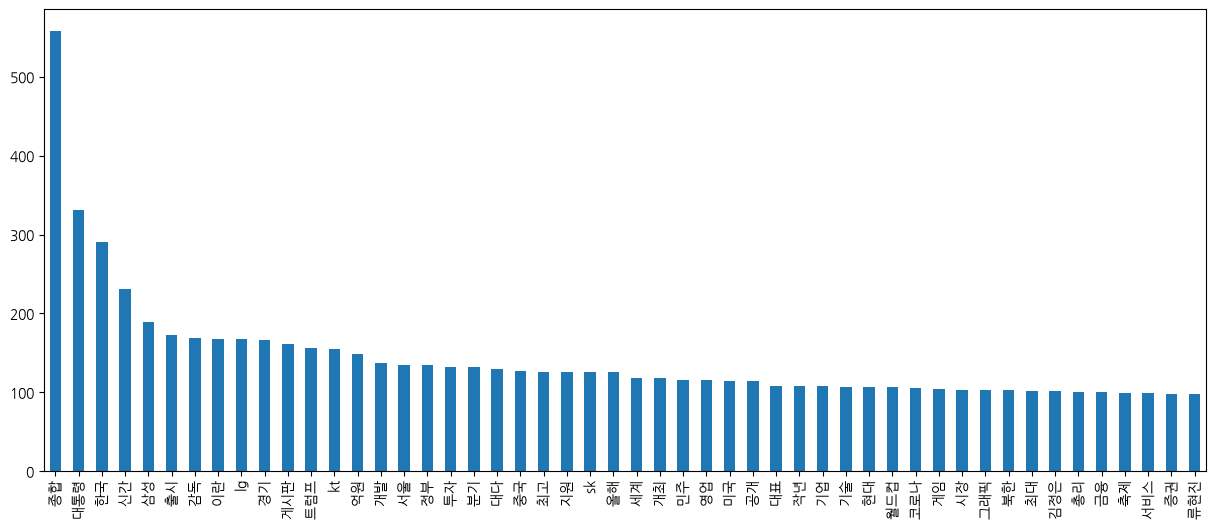

In [52]:
vocab_count.T[0].sort_values(ascending=False).head(50).plot.bar(figsize=(15, 6))
plt.show()

종합, 대통령, 한국, 신간, 삼성 등의 단어가 많이 추출됐다. 대통령은 주로 정치에 등장하지만 경제에 영향을 준 인물이나 스포츠 시상자로도 등장하기 때문에 전체 토픽에서 사용 빈도가 높게 나타난 것으로 보인다.

# 머신러닝을 이용해서 학습과 예측하기

## 랜덤 포레스트 분류기

학습은 랜덤 포레스트를 사용해서 진행한다. 랜덤 포레스트 트리 기반 알고리즘으로 의사결정 트리를 여러 개 만들어 학습과 예측을 한다. 그래서 트리 기반의 하이퍼파라미터를 가지고 있다.

사이킷런 라이브러리의 RandomForestClassifier()를 불러온다.  
`n_estimators`: 기본값은 100, 의사결정 트리의 개수를 지정한다. 많을수록 성능이 안정될 수 있으나 학습 시간이 길어진다.  
`max_depth`: 기본값은 None, 트리의 최대 깊이를 제한한다. `과적합을 방지`하기 위해 가장 자주 조절하는 파라미터이다.  
`min_samples_split`: 기본값은 2, 노드를 분할하기 위한 최소한의 샘플 데이터의 수를 지정한다. 이 값을 높이면 트리가 깊어지는 것은 방지한다.  
`min_samples_leaf`: 기본값은 1, 리프(단말) 노드가 되기 위한 최소한의 샘플 데이터 수를 지정한다. 불균형 데이터셋에서 유용하게 쓰인다.  
`max_features`: 기본값은 sqrt, 각 노드에서 분할에 사용할 최적의 피쳐 개수를 지정한다.  
&nbsp;&nbsp;&nbsp;sqrt: 전체 피쳐 중 제곱근만큼 선택한다. 분류에서 주로 사용  
&nbsp;&nbsp;&nbsp;log2: log<sub>2</sub>전체피쳐 만큼 선택한다.  
`bootstrap`: 기본값은 True, 데이터 샘플링 시 중복을 허용할지 여부를 결정한다.  
`max_samples`: 각 트리를 학습시킬 때 사용할 데이터 샘플의 비율이나 개수를 지정한다. bootstrap=True일 때만 사용 가능하다.  
`criterion`: 기본값은 gini, 분할의 품질을 측정하는 기준을 지정한다. gini(불순도) 또는 entropy(정보 이득)를 사용한다.  
`class_weight`: 데이터가 불균형할 때 클래스별 가중치를 설정한다. balanced로 설정하면 자동으로 비중에 맞게 조정된다.  
`n_jobs`: 학습 시 사용할 CPU 코어 개를 지정한다. -1로 설정하면 사용 가능한 모든 코어를 사용하여 속도를 높인다.  
`random_state`: 매번 실행할 때마다 결과가 달라지지 않도록 고정하는 난수 시드값을 지정한다.

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model

RandomForestClassifier(n_jobs=-1, random_state=42)

## 교차 검증(cross validation)

과적합을 피하고 모델에 가장 잘 맞는 결과를 얻기 위해 k폴드 교차 검증을 한다. 교차 검증을 시행하면 어떤 모델을 실제 서비스나 제품에 적용했을 때 좋은 성능을 낼지 측정하고, 모델의 성능을 개선할 수 있는 평가 지표값을 계산해 볼 수 있다.

<img src="./k폴드.png" width="800" align="left" />

전체 데이터셋을 학습 데이터셋과 테스트 데이터셋으로 구분하고 학습 데이터셋을 k개의 하위 데이터셋으로 분할한 후 교차 검증을 실행한다. 이때 테스트 데이터셋은 학습 데이터로 사용하지 않고 평가에만 사용한다.

이처럼 k개의 폴드로 나누어 검증하면 좀 더 정확한 성능을 측정할 수 있다.

In [55]:
from sklearn.model_selection import cross_val_predict

모델(model), 학습 데이터(x_train_tfidf), 학습 데이터에 따른 레이블(y_train)을 지정해서 교차 검증 모델을 만든다.  
cv: 교차 검증을 실행할 폴드의 개수를 지정한다.  
n_jobs: 교차 검증 시 사용할 CPU 코어 개를 지정한다.  
verbose: 교차 검증 작업이 진행되는 동안 화면에 출력되는 로그의 상세 수준을 조절한다.

In [56]:
%time y_pred = cross_val_predict(model, x_train_tfidf, y_train, cv=3, n_jobs=-1, verbose=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


CPU times: total: 453 ms
Wall time: 59.3 s


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   59.0s finished


교차 검증 정확도를 계산한다.

In [61]:
valid_accuracy = (y_pred == y_train).mean()
print(valid_accuracy)

0.7741928418101371


In [60]:
df_accuracy = pd.DataFrame({'예측값(y_pred)': y_pred, '실제값(y_train)': y_train})
df_accuracy['교차검증_정확도'] = (y_pred == y_train)
df_accuracy

,예측값(y_pred),실제값(y_train),교차검증_정확도
0,2.0,4.0,False
1,0.0,4.0,False
2,4.0,4.0,True
3,6.0,4.0,False
4,4.0,4.0,True
...,...,...,...
45649,1.0,1.0,True
45650,2.0,2.0,True
45651,1.0,1.0,True
45652,2.0,2.0,True


정확도가 아주 높은 것은 아니지만, 모델의 성능을 높이기 위한 최적화나 튜닝은 하지 않았다. 꾸준히 학습한다면 빠르고 적당한 성능을 내는 방법, 무겁지만 최고의 성능을 올리는 방법 등 여러 가지를 고려해 개선책을 모색해 볼 수 있을 것이다. 참고로 학습에 들어가기 전에 여러 방법을 통해 예측 비율을 높일 수 있다.

ㆍ전처리에서 불용어 리스트 추가  
ㆍBOW, TF-IDF의 파라미터 변경  
ㆍ분류기의 파라미터 변경  
ㆍ분류기 변경

## 학습

이제 fit() 메소드로 학습하고, predict() 메소드로 예측해서 우리가 만든 모델이 어느 정도 성능이 나오는지 알아본다.

In [62]:
# 학습 데이터와 학습 데이터에 따른 레이블을 넘겨서 학습시킨다.
%time model.fit(x_train_tfidf, y_train)

CPU times: total: 3min 25s
Wall time: 15 s


RandomForestClassifier(n_jobs=-1, random_state=42)

In [64]:
# 테스트 데이터를 넘겨서 예측한다.
y_predict = model.predict(x_test_tfidf)
y_predict[:20]

array([2., 3., 0., 2., 3., 0., 5., 3., 4., 4., 6., 6., 4., 0., 6., 1., 3.,
       2., 1., 4.])

완성된 모델에 새 데이터를 넣어서 예측하기

In [89]:
new_data = tfidfvect.transform([
    '데이터센터부터 엣지까지…인텔, 에이전틱 AI 아키텍처 3종 출격',           # IT과학
    'HD현대중공업 노사, 최종 조정 결렬…파업 전운 ‘고조’',                    # 경제
    '장미란씨 등 ‘실종 허위종결’ 경찰, 석방 하루만 영장실질심사',            # 사회
    '“240mm 더” 팰리세이드, 국내 최초 SUV 기반 ‘하이루프’ 모델 출시',        # 생활문화
    '중국 동참 없이는 놀랍지도 않은 ‘이란 왕따’ [트럼프 스톡커]',            # 세계
    '현실이 될지도 모를 LG 최악의 시나리오, 그래서 더 반가운 문정빈의 발견', # 스포츠
    '[속보] 李 “경찰 앞으로 가장 큰 권력... 국민 우려 커, 개혁기구 필요”'    # 정치
])
y_predict = model.predict(new_data)
y_predict

array([0., 2., 2., 0., 4., 0., 6.])

In [90]:
for i in y_predict:
    print(['IT과학, 0', '경제, 1', '사회, 2', '생활문화, 3', '세계, 4', '스포츠, 5', '정치, 6'][int(i)])

IT과학, 0
사회, 2
사회, 2
IT과학, 0
세계, 4
IT과학, 0
정치, 6
